Author(s) : Laura Gómez Navarro, Barbara Barcelo-Llull, ...

Objective: Describe xxx

Created on: May 2023


In [1]:
# _parcels_diag
import numpy as np
import netCDF4               as netcdf
import matplotlib.pyplot     as plt
import matplotlib.gridspec   as gridspec
import cartopy.crs           as ccrs
import cartopy.feature       as cfeature
import cartopy


In [2]:
# xx = ["40º 01.253' N", "1º 34.802' E"]
# --> check minutes in all!!

svp_038 = ["39º 38.74' N", "1º 25.42' E"]
svp_039 = ["39º 48.044' N", "1º 29.263' E"]
svp_040 = ["40º 01.298' N", "1º 34.860' E"]
svp_041 = ["39º 56.695' N", "1º 37.728' E"]
svp_042 = ["39º 52.800' N", "1º 40.125' E"]

her_001 = ["39º 56.695' N", "1º 37.728' E"]
her_002 = ["39º 52.800' N", "1º 40.125' E"]
her_003 = ["39º 48.266' N", "1º 42.948' E"]
her_004 = ["39º 47.923' N", "1º 44.759' E"]
her_006 = ["39º 49.125' N", "1º 41.076' E"]
her_007 = ["39º 50.358' N", "1º 37.329' E"]
her_008 = ["39º 51.202' N", "1º 40.180' E"]
her_009 = ["39º 49.995' N", "1º 43.748' E"]
her_010 = ["39º 52.075' N", "1º 42.719' E"]
her_011 = ["39º 53.400' N", "1º 38.700' E"]

car_001 = ["39º 38.74' N", "1º 25.42' E"] # lat , lon
car_002 = ["39º 48.044' N", "1º 29.263' E"] # lat , lon
car_003 = ["40º 01.253' N", "1º 34.802' E"] # lat , lon
car_004 = ["39º 48.523' N", "1º 42.934' E"] # lat , lon
car_005 = ["39º 49.706' N", "1º 39.316' E"] # lat , lon
car_006 = ["39º 50.968' N", "1º 35.389' E"] # lat , lon
car_007 = ["39º 51.942' N", "1º 37.896' E"] # lat , lon
car_008 = ["39º 50.488' N", "1º 42.076' E"] # lat , lon
car_009 = ["39º 51.495' N", "1º 44.500' E"] # lat , lon
car_010 = ["39º 52.819' N", "1º 40.540' E"] # lat , lon

# --> info. from logs

In [3]:
svp_leg1 = [svp_038, svp_039, svp_040, svp_041
              , svp_042]

In [4]:
her_leg1 = [her_001, her_002, her_003, her_004
              , her_006, her_007, her_008, her_009
              , her_010, her_011]

In [5]:
car_leg1 = [car_001, car_002, car_003
                ,car_004, car_005, car_006, car_007, car_008
                ,car_009, car_010]

## Converting it to decimal degrees:

In [6]:
xx = ["40º 01.253' N", "1º 34.802' E"]
xx[0] = float(xx[0].split(' ')[0][0:-1]) + (float((xx[0].split(' ')[1][0:-1])) / 60.)
xx[1] = float(xx[1].split(' ')[0][0:-1]) + (float((xx[1].split(' ')[1][0:-1])) / 60.)

In [7]:
for ii in range(0, len(svp_leg1)):
    xx = svp_leg1[ii]
    xx[0] = float(xx[0].split(' ')[0][0:-1]) + (float((xx[0].split(' ')[1][0:-1])) / 60.)
    xx[1] = float(xx[1].split(' ')[0][0:-1]) + (float((xx[1].split(' ')[1][0:-1])) / 60.)

In [8]:
svp_leg1

[[39.64566666666666, 1.4236666666666666],
 [39.80073333333333, 1.4877166666666666],
 [40.021633333333334, 1.581],
 [39.944916666666664, 1.6288],
 [39.88, 1.66875]]

In [9]:
for ii in range(0, len(her_leg1)):
    xx = her_leg1[ii]
    xx[0] = float(xx[0].split(' ')[0][0:-1]) + (float((xx[0].split(' ')[1][0:-1])) / 60.)
    xx[1] = float(xx[1].split(' ')[0][0:-1]) + (float((xx[1].split(' ')[1][0:-1])) / 60.)

In [10]:
her_leg1

[[39.944916666666664, 1.6288],
 [39.88, 1.66875],
 [39.804433333333336, 1.7158],
 [39.798716666666664, 1.7459833333333332],
 [39.81875, 1.6846],
 [39.8393, 1.62215],
 [39.853366666666666, 1.6696666666666666],
 [39.83325, 1.7291333333333334],
 [39.867916666666666, 1.7119833333333334],
 [39.89, 1.645]]

In [11]:
for ii in range(0, len(car_leg1)):
    xx = car_leg1[ii]
    xx[0] = float(xx[0].split(' ')[0][0:-1]) + (float((xx[0].split(' ')[1][0:-1])) / 60.)
    xx[1] = float(xx[1].split(' ')[0][0:-1]) + (float((xx[1].split(' ')[1][0:-1])) / 60.)

In [12]:
car_leg1

[[39.64566666666666, 1.4236666666666666],
 [39.80073333333333, 1.4877166666666666],
 [40.02088333333333, 1.5800333333333332],
 [39.80871666666667, 1.7155666666666667],
 [39.82843333333334, 1.6552666666666667],
 [39.849466666666665, 1.5898166666666667],
 [39.8657, 1.6316000000000002],
 [39.84146666666667, 1.7012666666666667],
 [39.85825, 1.7416666666666667],
 [39.880316666666666, 1.6756666666666666]]

In [13]:
her_005 = [39.7646, 1.7164]
her_012 = [39.7199, 1.7298]
her_013 = [39.5155, 1.6714]
her_014 = [39.586, 1.650]
her_015 = [39.6563, 1.4475]
her_016 = [39.6791, 1.4997]
her_017 = [39.6230, 1.4749]
her_018 = [39.6451, 1.5768]
her_019 = [39.5911, 1.5013]
her_020 = [39.6114, 1.5498]

car_011 = [39.7014, 1.7331] # lat , lon
car_012 = [39.5947, 1.7673] # lat , lon
car_013 = [39.7058, 1.6147] # lat , lon
car_014 = [39.7803, 1.5925] # lat , lon
car_015 = [39.6548, 1.4959] # lat , lon
car_016 = [39.6437, 1.4714] # lat , lon
car_017 = [39.6120, 1.4481] # lat , lon
car_018 = [39.6556, 1.5526] # lat , lon
car_019 = [39.6215, 1.5207] # lat , lon
car_020 = [39.6107, 1.4945] # lat , lon

# --> info. from logs

In [14]:
her_leg2 = [her_005, her_012, her_013, her_014
              , her_015, her_016, her_017, her_018, her_019
               , her_020]

In [15]:
car_leg2 = [car_011, car_012, car_013
                        ,car_014, car_015, car_016, car_017, car_018
                        ,car_019, car_020]

# SWOT swath data

In [16]:
dir_swaths = 'elisabet/'
    
file_swaths1 = 'MED_fastPhase_1km_swotFAST_grid_p009.nc'
file_swaths2 = 'MED_fastPhase_1km_swotFAST_grid_p022.nc'

nc    = netcdf.Dataset(dir_swaths + file_swaths1, 'r')
latsw1  = nc.variables['lat'][:]   
lonsw1  = nc.variables['lon'][:]  
x_ac1   = nc.variables['x_ac'][:]  # "Across track distance from nadir"

lonnd1  = nc.variables['lon_nadir'][:] 
latnd1  = nc.variables['lat_nadir'][:] 
nc.close()     

nc    = netcdf.Dataset(dir_swaths + file_swaths2, 'r')
latsw2  = nc.variables['lat'][:]   
lonsw2  = nc.variables['lon'][:]  
x_ac2   = nc.variables['x_ac'][:]  # "Across track distance from nadir"

lonnd2  = nc.variables['lon_nadir'][:] 
latnd2  = nc.variables['lat_nadir'][:]     

nc.close()  

# Drifter deployments:

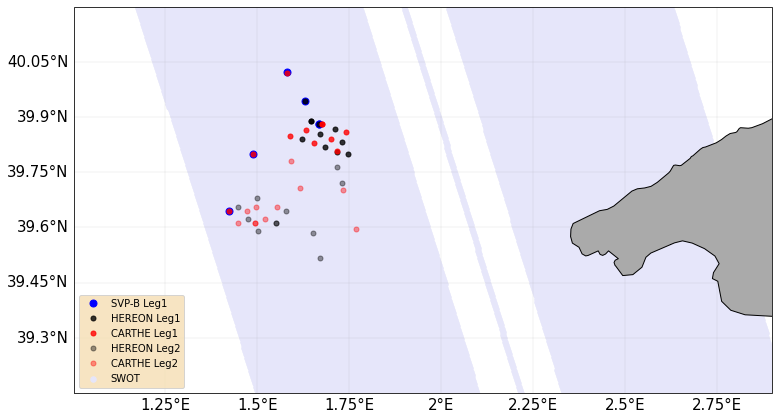

In [36]:
msize = 10  # marker size
fsize = 16 # text size

fig = plt.figure(figsize=(10,7))

gs  = gridspec.GridSpec(1, 1)
ax  = plt.subplot(gs[0,0], projection=ccrs.PlateCarree())

############ 
for svp in svp_leg1:
    ax.plot(svp[1], svp[0], '.', c='b', markersize=14, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(svp[1], svp[0], '.', c='b', markersize=14, zorder=4, transform=ccrs.PlateCarree(), label='SVP-B Leg1') # to add just to legend once

for her in her_leg1:
    ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, alpha=.8, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, alpha=.8, transform=ccrs.PlateCarree(), label='HEREON Leg1') # to add just to legend once

for car in car_leg1:
    ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, alpha=.8, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, alpha=.8, transform=ccrs.PlateCarree(), label='CARTHE Leg1') # to add just to legend once


for her in her_leg2:
    ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, alpha=.4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, alpha=.4, transform=ccrs.PlateCarree(), label='HEREON Leg2') # to add just to legend once

for car in car_leg2:
    ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, alpha=.4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, alpha=.4, transform=ccrs.PlateCarree(), label='CARTHE Leg2') # to add just to legend once

#######

############ 
# SWOT swaths
ax.scatter(lonsw1.flatten(), latsw1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree()) #s=msize/25
ax.scatter(lonsw2.flatten(), latsw2.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd1.flatten(), latnd1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd2.flatten(), latnd2.flatten(), c='lavender', s=30, zorder=1, label='SWOT',
                transform=ccrs.PlateCarree())
    
############ 

# title
# ax.set_title('FaSt-SWOT2 sampling', fontsize = 18)

# Grid and ticks
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.2, color='gray', alpha=0.5, linestyle='-')

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
# domain extent
dsm = 1
dbg = 1
ax.set_extent([1., 2.9, 
              39.15, 40.2], crs=ccrs.PlateCarree())

# ax.set_extent([lon_south.min()-dsm, lon_north.max()+dbg, 
#                lat_north.min()-dsm/2-0.3, lat_south.max()+dsm/2+0.1], crs=ccrs.PlateCarree())

#Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax.add_feature(feature)

ax.legend(facecolor='wheat') #wheat
plt.tight_layout()
    
fig.savefig(#dir_fig + 
                'drifters_dep_FaSt-SWOT.png', 
                dpi=400)  
    

# No SVPs:

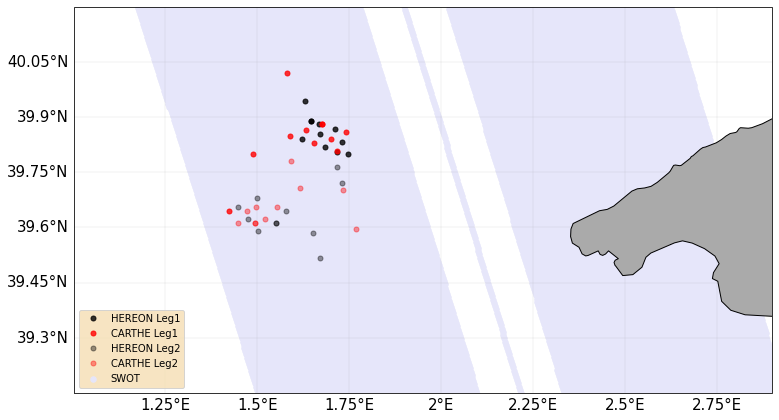

In [37]:
msize = 10  # marker size
fsize = 16 # text size

fig = plt.figure(figsize=(10,7))

gs  = gridspec.GridSpec(1, 1)
ax  = plt.subplot(gs[0,0], projection=ccrs.PlateCarree())

############ 
for her in her_leg1:
    ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, alpha=.8, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, alpha=.8, transform=ccrs.PlateCarree(), label='HEREON Leg1') # to add just to legend once

for car in car_leg1:
    ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, alpha=.8, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, alpha=.8, transform=ccrs.PlateCarree(), label='CARTHE Leg1') # to add just to legend once


for her in her_leg2:
    ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, alpha=.4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, alpha=.4, transform=ccrs.PlateCarree(), label='HEREON Leg2') # to add just to legend once

for car in car_leg2:
    ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, alpha=.4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, alpha=.4, transform=ccrs.PlateCarree(), label='CARTHE Leg2') # to add just to legend once

#######

############ 
# SWOT swaths
ax.scatter(lonsw1.flatten(), latsw1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree()) #s=msize/25
ax.scatter(lonsw2.flatten(), latsw2.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd1.flatten(), latnd1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd2.flatten(), latnd2.flatten(), c='lavender', s=30, zorder=1, label='SWOT',
                transform=ccrs.PlateCarree())
    
############ 

# title
# ax.set_title('FaSt-SWOT2 sampling', fontsize = 18)

# Grid and ticks
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.2, color='gray', alpha=0.5, linestyle='-')

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
# domain extent
dsm = 1
dbg = 1
ax.set_extent([1., 2.9, 
              39.15, 40.2], crs=ccrs.PlateCarree())

# ax.set_extent([lon_south.min()-dsm, lon_north.max()+dbg, 
#                lat_north.min()-dsm/2-0.3, lat_south.max()+dsm/2+0.1], crs=ccrs.PlateCarree())

#Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax.add_feature(feature)

ax.legend(facecolor='wheat') #wheat
plt.tight_layout()
    
fig.savefig(#dir_fig + 
                'drifters_dep_FaSt-SWOT_noSVPs.png', 
                dpi=400)  
    

# Sublot per Leg:

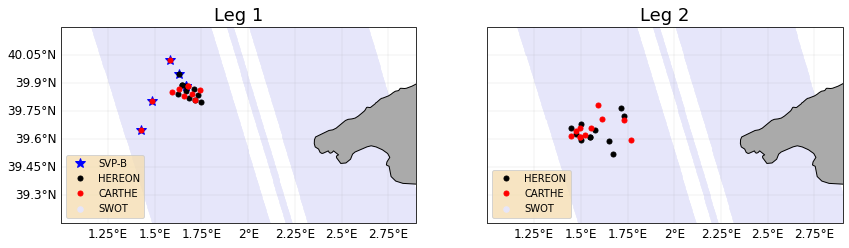

In [45]:
msize = 10  # marker size
fsize = 16 # text size

fig = plt.figure(figsize=(14,7))

gs  = gridspec.GridSpec(1, 2)

#%%%%%%%%%%%%%%%
ax  = plt.subplot(gs[0,0], projection=ccrs.PlateCarree())

############ 
for svp in svp_leg1:
    ax.plot(svp[1], svp[0], '*', c='b', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(svp[1], svp[0], '*', c='b', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='SVP-B') # to add just to legend once

for her in her_leg1:
    ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='HEREON') # to add just to legend once

for car in car_leg1:
    ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='CARTHE') # to add just to legend once

#######

############ 
# SWOT swaths
ax.scatter(lonsw1.flatten(), latsw1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree()) #s=msize/25
ax.scatter(lonsw2.flatten(), latsw2.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd1.flatten(), latnd1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd2.flatten(), latnd2.flatten(), c='lavender', s=30, zorder=1, label='SWOT',
                transform=ccrs.PlateCarree())
    
############ 

# title
ax.set_title('Leg 1', fontsize = 18)

# Grid and ticks
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.2, color='gray', alpha=0.5, linestyle='-')

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize-4}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-4}#, 'color': 'gray'}
  
# domain extent
dsm = 1
dbg = 1
ax.set_extent([1., 2.9, 
              39.15, 40.2], crs=ccrs.PlateCarree())

# ax.set_extent([lon_south.min()-dsm, lon_north.max()+dbg, 
#                lat_north.min()-dsm/2-0.3, lat_south.max()+dsm/2+0.1], crs=ccrs.PlateCarree())

#Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax.add_feature(feature)

ax.legend(facecolor='wheat') #wheat
####%%%%%%%%%%%%%%%%%%%
#%%%%%%%%%%%%%%%
ax  = plt.subplot(gs[0,1], projection=ccrs.PlateCarree())

############ 
for her in her_leg2:
    ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='HEREON') # to add just to legend once

for car in car_leg2:
    ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='CARTHE') # to add just to legend once

#######

############ 
# SWOT swaths
ax.scatter(lonsw1.flatten(), latsw1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree()) #s=msize/25
ax.scatter(lonsw2.flatten(), latsw2.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd1.flatten(), latnd1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd2.flatten(), latnd2.flatten(), c='lavender', s=30, zorder=1, label='SWOT',
                transform=ccrs.PlateCarree())
    
############ 

# title
ax.set_title('Leg 2', fontsize = 18)

# Grid and ticks
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.2, color='gray', alpha=0.5, linestyle='-')

gl.top_labels = False
gl.right_labels = False
gl.left_labels = False

gl.xlabel_style = {'size': fsize-4}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-4}#, 'color': 'gray'}
  
# domain extent
dsm = 1
dbg = 1
ax.set_extent([1., 2.9, 
              39.15, 40.2], crs=ccrs.PlateCarree())

# ax.set_extent([lon_south.min()-dsm, lon_north.max()+dbg, 
#                lat_north.min()-dsm/2-0.3, lat_south.max()+dsm/2+0.1], crs=ccrs.PlateCarree())

#Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax.add_feature(feature)

ax.legend(facecolor='wheat') #wheat


# plt.tight_layout()
    
fig.savefig(#dir_fig + 
                'drifters_dep_FaSt-SWOT_Leg_Subplots.png', 
                dpi=400)  
    

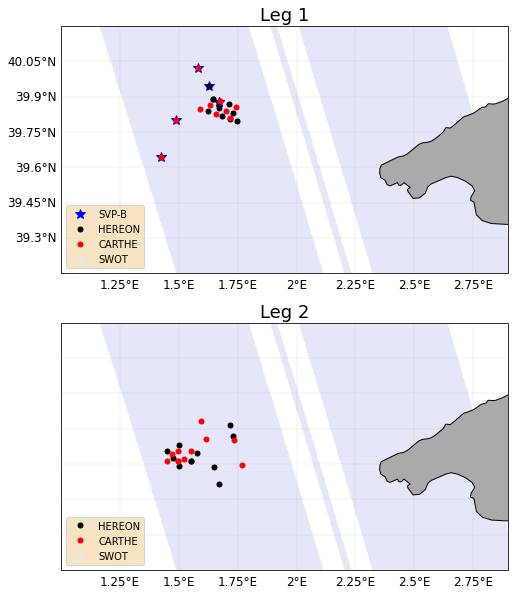

In [18]:
msize = 10  # marker size
fsize = 16 # text size

fig = plt.figure(figsize=(10,10))

gs  = gridspec.GridSpec(2, 1)

#%%%%%%%%%%%%%%%
ax  = plt.subplot(gs[0], projection=ccrs.PlateCarree())

############ 
for svp in svp_leg1:
    ax.plot(svp[1], svp[0], '*', c='b', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(svp[1], svp[0], '*', c='b', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='SVP-B') # to add just to legend once

for her in her_leg1:
    ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='HEREON') # to add just to legend once

for car in car_leg1:
    ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='CARTHE') # to add just to legend once

#######

############ 
# SWOT swaths
ax.scatter(lonsw1.flatten(), latsw1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree()) #s=msize/25
ax.scatter(lonsw2.flatten(), latsw2.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd1.flatten(), latnd1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd2.flatten(), latnd2.flatten(), c='lavender', s=30, zorder=1, label='SWOT',
                transform=ccrs.PlateCarree())
    
############ 

# title
ax.set_title('Leg 1', fontsize = 18)

# Grid and ticks
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.2, color='gray', alpha=0.5, linestyle='-')

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize-4}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-4}#, 'color': 'gray'}
  
# domain extent
dsm = 1
dbg = 1
ax.set_extent([1., 2.9, 
              39.15, 40.2], crs=ccrs.PlateCarree())

# ax.set_extent([lon_south.min()-dsm, lon_north.max()+dbg, 
#                lat_north.min()-dsm/2-0.3, lat_south.max()+dsm/2+0.1], crs=ccrs.PlateCarree())

#Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax.add_feature(feature)

ax.legend(facecolor='wheat') #wheat
####%%%%%%%%%%%%%%%%%%%
#%%%%%%%%%%%%%%%
ax  = plt.subplot(gs[1], projection=ccrs.PlateCarree())

############ 
for her in her_leg2:
    ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(her[1], her[0], '.', c='k', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='HEREON') # to add just to legend once

for car in car_leg2:
    ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, transform=ccrs.PlateCarree()) #, markeredgecolor='w'
ax.plot(car[1], car[0], '.', c='r', markersize=10, zorder=4, transform=ccrs.PlateCarree(), label='CARTHE') # to add just to legend once

#######

############ 
# SWOT swaths
ax.scatter(lonsw1.flatten(), latsw1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree()) #s=msize/25
ax.scatter(lonsw2.flatten(), latsw2.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd1.flatten(), latnd1.flatten(), c='lavender', s=30, zorder=1,
                transform=ccrs.PlateCarree())
ax.scatter(lonnd2.flatten(), latnd2.flatten(), c='lavender', s=30, zorder=1, label='SWOT',
                transform=ccrs.PlateCarree())
    
############ 

# title
ax.set_title('Leg 2', fontsize = 18)

# Grid and ticks
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.2, color='gray', alpha=0.5, linestyle='-')

gl.top_labels = False
gl.right_labels = False
gl.left_labels = False

gl.xlabel_style = {'size': fsize-4}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize-4}#, 'color': 'gray'}
  
# domain extent
dsm = 1
dbg = 1
ax.set_extent([1., 2.9, 
              39.15, 40.2], crs=ccrs.PlateCarree())

# ax.set_extent([lon_south.min()-dsm, lon_north.max()+dbg, 
#                lat_north.min()-dsm/2-0.3, lat_south.max()+dsm/2+0.1], crs=ccrs.PlateCarree())

#Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax.add_feature(feature)

ax.legend(facecolor='wheat') #wheat


# plt.tight_layout()
    
fig.savefig(#dir_fig + 
                'drifters_dep_FaSt-SWOT_Leg_Subplots_vertical.png', 
                dpi=400)  
    